# Bài tập Chương 2

Nội dung:
1. Perceptron
2. Hàm kích hoạt
3. Dữ liệu MNIST
4. Xây dựng mô hình nhận dạng


## 1. Perceptron cho bài toán logic OR

Yêu cầu:
1. Tạo tập dữ liệu cho bài toán OR
2. Khởi tạo trọng số và bias
3. Xây dựng hàm dự đoán của perceptron
4. Viết thuật toán cập nhật trọng số
5. Huấn luyện mô hình
6. Kiểm tra lại kết quả dự đoán

Gợi ý:
- Sử dụng hàm kích hoạt step function
- Cập nhật trọng số theo quy tắc học của perceptron
- Lặp nhiều epoch để hội tụ

In [ ]:
# TODO:
import numpy as np

#1. Tạo tập dữ liệu cho bài toán OR
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([0, 1, 1, 1]) # OR logic gate output - label

#2. Khởi tạo trọng số và bias
w = np.random.randn(2) # weights randomly initialized 
b = np.random.randn() # bias


#3. Xây dựng hàm dự đoán của perceptron
def predict(X):
    linear_output = np.dot(X, w) + b
    predicted = np.where(linear_output >= 0, 1, 0)
    return predicted

#4. Viết thuật toán cập nhật trọng số
def train(X, y, learning_rate=0.1, epochs=10):
    global w, b
    for epoch in range(epochs):
        for i in range(len(X)):
            y_pred = predict(X[i])
            error = y[i] - y_pred
            w += learning_rate * error * X[i]
            b += learning_rate * error
            
#5. Huấn luyện mô hình
train(X, y, learning_rate=0.1, epochs=10)

#6. Kiểm tra lại kết quả dự đoán sau khi huấn luyện
print("Final weights:", w)
print("Final bias:", b)
print("Predictions after training:")
for i in range(len(X)):
    print(f"Input: {X[i]}, Predicted: {predict(X[i])}, Actual: {y[i]}")

Final weights: [-0.18227255 -0.16870733]
Final bias: 0.5058505941327951
Predictions after training:
Input: [0 0], Predicted: 1, Actual: 0
Input: [0 1], Predicted: 1, Actual: 1
Input: [1 0], Predicted: 1, Actual: 1
Input: [1 1], Predicted: 1, Actual: 1


## 2. Hàm kích hoạt

### 2.1 ReLU
Yêu cầu:
1. Cài đặt hàm ReLU
2. Tạo dữ liệu x trong khoảng [-10, 10]
3. Vẽ đồ thị

Gợi ý:
- ReLU(x) = max(0, x)

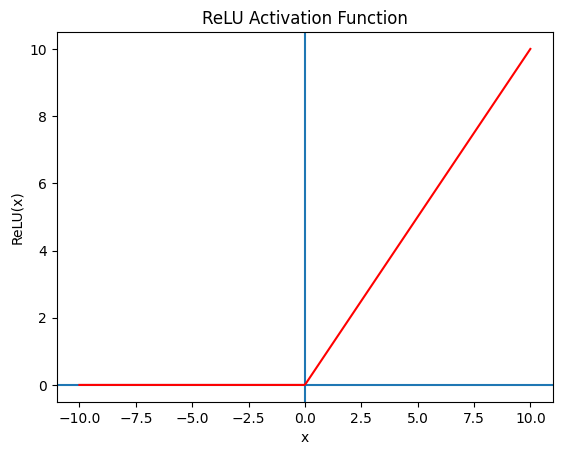

In [18]:
# TODO:
import matplotlib.pyplot as plt

#1. Cài đặt hàm ReLU
def relu(x):
    return np.maximum(0, x)

#2. Tạo dữ liệu x trong khoảng [-10, 10]
x = np.linspace(-10, 10, 400)
y = relu(x)

#3. Vẽ đồ thị
plt.title('ReLU Activation Function')
plt.xlabel("x")
plt.ylabel("ReLU(x)")

plt.axhline(0)
plt.axvline(0)

plt.plot(x, y, color='red')
plt.show()

### 2.2 Sigmoid

Yêu cầu:
1. Cài đặt hàm sigmoid
2. Vẽ đồ thị hàm sigmoid với $x \in [-10, 10]$

Gợi ý:
- $ sigmoid(x) = 1 / (1 + e^{-x}) $

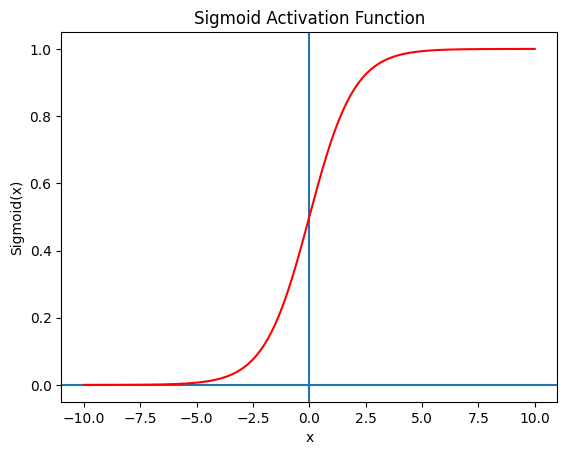

In [ ]:
# TODO: 
#1. Cài đặt hàm sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

#2. Vẽ đồ thị hàm sigmoid với $x \in [-10, 10]
x = np.linspace(-10, 10, 400)
y = sigmoid(x)
plt.title('Sigmoid Activation Function')
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.axhline(0)
plt.axvline(0)
plt.plot(x, y, color='red')
plt.show()

## 3. Làm việc với dữ liệu MNIST

Yêu cầu:
1. Tải dữ liệu MNIST
2. In kích thước tập train và test
3. Hiển thị 10 ảnh mẫu
4. Chuẩn hóa dữ liệu về khoảng [0,1]

Gợi ý:
- Sử dụng keras.datasets
- Dữ liệu ảnh có kích thước 28x28

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


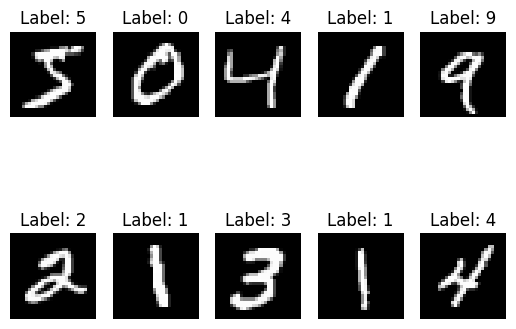

Data normalized. Sample pixel value: 0.0


In [4]:
# TODO:
#Gợi ý:
#- Sử dụng keras.datasets
#- Dữ liệu ảnh có kích thước 28x28
#1. Tải dữ liệu MNIST
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

#2. In kích thước tập train và test
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

#3. Hiển thị 10 ảnh mẫu
for i in range(10):
    plt.subplot(2, 5, i + 1)   # tạo lưới 2 hàng 5 cột
    plt.imshow(X_train[i], cmap='gray')  # hiển thị ảnh grayscale
    plt.title(f"Label: {y_train[i]}")    # hiển thị nhãn
    plt.axis('off')                     # tắt trục

plt.show()
#4. Chuẩn hóa dữ liệu về khoảng [0,1]
X_train = X_train / 255.0
X_test = X_test / 255.0
print("Data normalized. Sample pixel value:", X_train[0][0][0])


## 4. Xây dựng mô hình nhận dạng chữ số

Yêu cầu:
1. Xây dựng mô hình neural network đơn giản
2. Compile mô hình (loss, optimizer, metrics)
3. Huấn luyện mô hình
4. Đánh giá trên tập test
5. Dự đoán một số ảnh

Gợi ý:
- Sử dụng Dense layers
- Hàm kích hoạt ReLU cho hidden layer
- Softmax cho output

In [5]:
# TODO: Xây dựng và huấn luyện mô hình MNIST
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

#1. Xây dựng mô hình neural network đơn giản
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # chuyển ảnh 28x28 thành vector 784 chiều
    layers.Dense(128, activation='relu'),   # lớp ẩn với 128 neuron và ReLU activation
    layers.Dense(10, activation='softmax')  # lớp output với 10 neuron (cho 10 lớp) và softmax activation
])

#2. Compile mô hình (loss, optimizer, metrics)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#3. Huấn luyện mô hình
model.fit(X_train, y_train, epochs=5, batch_size=32)

#4. Đánh giá trên tập test
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")

#5. Dự đoán một số ảnh
predictions = model.predict(X_test[:10])
print("Predictions:", predictions)

/home/zhu/micromamba/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1774518880.467548   92313 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774518880.561658   92313 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9249 - loss: 0.2631
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9659 - loss: 0.1160
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9761 - loss: 0.0795
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9816 - loss: 0.0607
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9857 - loss: 0.0464
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9780 - loss: 0.0748
Test accuracy: 0.9779999852180481
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Predictions: [[5.75777648e-08 2.60585498e-10 4.22508447e-06 6.71290909e-05
  5.87055361e-12 7.81083358e-08 7.75662867e-12 9.99927878e-01
  3.93127124e-07 2.23563021e-07]
 [1.09163734e-09 1.21120302e-05 9.99987245e-01 3.41605698e-07
  8.43897072e-16 1.52581435e-07 1.05605423e-07 1.28481386e-13
  5.23641752e-09 5.86657594e-14]
 [1.18228934e-06 9.97135520e-01 3.27105663e-04 5.15999309e-05
  1.81436000e-04 4.9018

## 5. Phân loại tập dữ liệu hoa Iris

### 5.1. Tải tập dữ liệu hoa Iris. Sau đó in các thông tin sau:
- In số dòng và số cột của tập dữ liệu.
- In tên các loại (nhãn) dữ liệu.
- In 5 dòng dữ liệu đầu tiên.
- Chia tập dữ liệu thành hai phần: tập train chiếm 70%, tập test chiếm 30%.

In [10]:
# TODO:
#1. Tải tập dữ liệu hoa Iris
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

#in số dòng và số cột của dữ liệu
print("Data shape:", X.shape)

#in 5 dòng đầu tiên của dữ liệu
print("First 5 rows of data:\n", X[:5])

#2. Chia dữ liệu thành tập train và test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)
First 5 rows of data:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Training data shape: (105, 4)
Test data shape: (45, 4)


### 5.2. Xây dựng DNN để phân loại hoa Iris

In [ ]:
# TODO: Xây dụng DNN để phân loại hoa Iris
from tensorflow.keras import layers
from tensorflow.keras import models
#1. Xây dựng mô hình DNN
model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(4,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(3, activation='softmax'))  # 3 lớp hoa Iris
#2. Compile mô hình
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#3. Huấn luyện mô hình 
model.fit(X_train, y_train, epochs=10, batch_size=16)
#4. Đánh giá trên tập test
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")
#5. Dự đoán một số mẫu
predictions = model.predict(X_test[:5])
print("Predictions:", predictions)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3905 - loss: 1.3750  
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4190 - loss: 0.9854
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3810 - loss: 0.9549 
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7714 - loss: 0.8485 
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7810 - loss: 0.7782 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8286 - loss: 0.7189 
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8286 - loss: 0.6646
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8381 - loss: 0.6316
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8286 - loss: 0.5775 
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7238 - loss: 0.5430 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9333 - loss: 0.4516 
Test accuracy: 0.9333333373069763
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predictions: [[0.079465

### 5.3. Classification Report

- Tìm hiểu Classification Report là gì? Công dụng của nó?

 
 Classification Report là một báo cáo đánh giá hiệu năng mô hình phân loại (classification). Nó tổng hợp các chỉ số chính:
    
    - Precision
    - Recall
    - F1-score
    - Support (số mẫu thực tế của mỗi lớp)

 Classification Report giúp người học đánh giá từng lớp cho biết lớp nào model dự đoán tốt, lớp nào kém. Cân bằng giữa độ chính xác và độ nhạy F1-score cho phép ra quyết định khi dữ liệu bị lệch lớp (imbalanced). Dùng để so sánh nhanh performance giữa các mô hình hoặc cấu hình khác nhau.Dễ dàng phát hiện “false positive/negative” qua precision/recall.

- In Classification Report.

In [ ]:
#TODO: # Classification Report
from sklearn.metrics import classification_report
import numpy as np
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes, target_names=iris.target_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.77      0.87        13
   virginica       0.81      1.00      0.90        13

    accuracy                           0.93        45
   macro avg       0.94      0.92      0.92        45
weighted avg       0.95      0.93      0.93        45



### 5.4. Confusion Matrix
- Tìm hiểu Confusion Matrix là gì? Công dụng của nó?

 Confusion Matrix là ma trận 2D dùng để biểu diễn kết quả dự đoán của mô hình phân loại với giá trị thực tế. Nó bao gồm có:

    - Hàng: nhãn thực (actual)
    - Cột: nhãn dự đoán (predicted)
    - Mỗi ô ở vị trí (i, j): số mẫu thực là i được dự đoán thành j.

 Confusion Matrix hiển thị chi tiết

 True Positive (TP), True Negative (TN)
 False Positive (FP), False Negative (FN)

 Giúp người học phân tích lỗi nắm rõ loại lỗi hoặc nhầm lớp nào sang lớp nào. Đánh giá imbalance cho thấy mô hình ưu tiên lớp nào, bỏ quên lớp nào

- Vẽ Confusion Matrix.

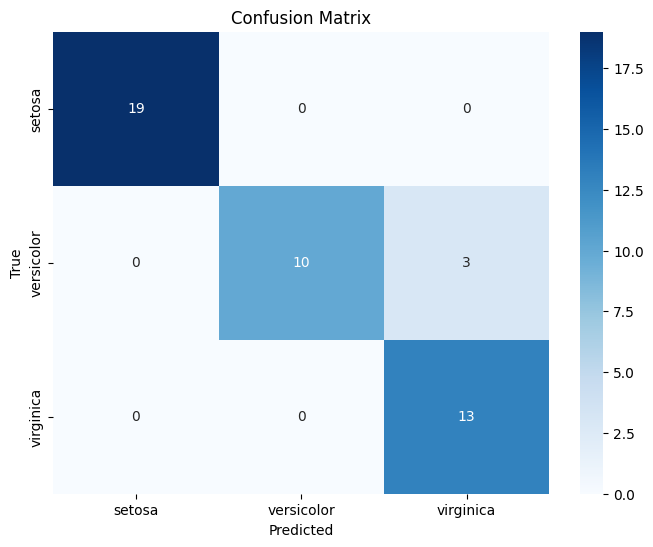

In [19]:
#TODO: Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()